In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
#torch.manual_seed(42)
#np.random.seed(42)

def soft_min(a, gamma):
    """
    Compute soft-minimum of values using LogSumExp trick.
    a: tensor of shape (3,) containing [d[i-1,j], d[i,j-1], d[i-1,j-1]]
       or similarly batched but simpler for now.
    Actually we can use torch.logsumexp directly.
    softmin_gamma(x) = -gamma * log(sum(exp(-x/gamma)))
    """
    return -gamma * torch.logsumexp(-a / gamma, dim=0)

class SoftDTW(nn.Module):
    def __init__(self, gamma=1.0):
        super(SoftDTW, self).__init__()
        self.gamma = gamma

    def forward(self, x, y):
        """
        Compute Soft-DTW distance between x and y.
        x: (seq_len_x, dim) or (seq_len_x,)
        y: (seq_len_y, dim) or (seq_len_y,)
        Returns scalar distance.
        """
        if x.dim() == 1: x = x.unsqueeze(1)
        if y.dim() == 1: y = y.unsqueeze(1)
            
        n, m = x.shape[0], y.shape[0]
        
        # Initialize DP table (using a slightly larger size for boundary conditions)
        # However, for autograd to track operations properly, we build it step-by-step.
        # We can't do in-place modification on a leaf tensor requiring grad efficiently in loop if not careful.
        # But for small n,m, we can just build a list of lists or similar structure.
        
        # DP table initialization
        # Size (n+1, m+1)
        # r[0,0] = 0, others infinity.
        
        # We need to be careful. Creating a tensor of zeros and updating index by index
        # breaks the computational graph in some cases or is very inefficient.
        # But let's try a simple list of lists of tensors first.
        
        # Precompute distances
        # dist_matrix: (n, m)
        dist_matrix = torch.cdist(x, y, p=2).pow(2) # Squared Euclidean distance
        
        # DP with softmin
        # We'll store values in a dict or list for now
        
        # R = torch.full((n + 1, m + 1), float('inf')) cannot be used easily with autograd this way 
        # unless we construct it carefully. 
        
        # Let's use a list of lists.
        # R[i][j] stores the value at i, j
        
        R = [[None for _ in range(m + 1)] for _ in range(n + 1)]
        
        # Initialize boundaries
        R[0][0] = torch.tensor(0.0)
        
        for i in range(1, n + 1):
            R[i][0] = torch.tensor(1e10) # effectively infinity
        for j in range(1, m + 1):
            R[0][j] = torch.tensor(1e10)
            
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                # Cost at (i, j)
                cost = dist_matrix[i-1, j-1]
                
                # Neighbors
                r0 = R[i-1][j]
                r1 = R[i][j-1]
                r2 = R[i-1][j-1]
                
                # Softmin
                # Stack them to use logsumexp
                neighbors = torch.stack([r0, r1, r2])
                min_val = soft_min(neighbors, self.gamma)
                
                R[i][j] = cost + min_val
                
        return R[n][m]

# Verification of implementation
# Create dummy data
x_dummy = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y_dummy = torch.tensor([1.0, 2.0, 3.0])
sdtw = SoftDTW(gamma=1.0)
loss = sdtw(x_dummy, y_dummy)
print(f"Soft-DTW distance: {loss.item()}")

loss.backward()
print(f"Gradient w.r.x: {x_dummy.grad}")

Soft-DTW distance: -1.190427541732788
Gradient w.r.x: tensor([-4.7519e-01, -2.9802e-08,  4.7519e-01])


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

def soft_min(a, gamma):
    """
    Compute soft-minimum of values using LogSumExp trick.
    a: tensor of shape (3,) containing [d[i-1,j], d[i,j-1], d[i-1,j-1]]
    """
    # softmin_gamma(x) = -gamma * log(sum(exp(-x/gamma)))
    # For stability, we use logsumexp which computes log(sum(exp(x)))
    # So we compute -gamma * logsumexp(-a/gamma)
    return -gamma * torch.logsumexp(-a / gamma, dim=0)

class SoftDTW(nn.Module):
    def __init__(self, gamma=1.0):
        super(SoftDTW, self).__init__()
        self.gamma = gamma

    def forward(self, x, y):
        """
        Compute Soft-DTW distance between x and y.
        x: (seq_len_x, dim) or (seq_len_x,)
        y: (seq_len_y, dim) or (seq_len_y,)
        Returns scalar distance.
        """
        if x.dim() == 1: x = x.unsqueeze(1)
        if y.dim() == 1: y = y.unsqueeze(1)
            
        n, dim_x = x.shape
        m, dim_y = y.shape
        
        # Compute pairwise squared Euclidean distances
        # (n, 1, d) - (1, m, d) -> (n, m, d) -> sum squ -> (n, m)
        dist_matrix = torch.sum((x[:, None, :] - y[None, :, :]) ** 2, dim=2)
        
        # DP Initialization (Use a list of lists for autograd tracking)
        # Initialize with large values representing infinity
        INF = 1e10
        dp = [[torch.tensor(INF) for _ in range(m + 1)] for _ in range(n + 1)]
        
        dp[0][0] = torch.tensor(0.0)
        
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                cost = dist_matrix[i-1, j-1]
                
                # Neighbors: (i-1, j), (i, j-1), (i-1, j-1)
                neighbors = torch.stack([
                    dp[i-1][j],
                    dp[i][j-1],
                    dp[i-1][j-1]
                ])
                
                dp[i][j] = cost + soft_min(neighbors, self.gamma)
                
        return dp[n][m]


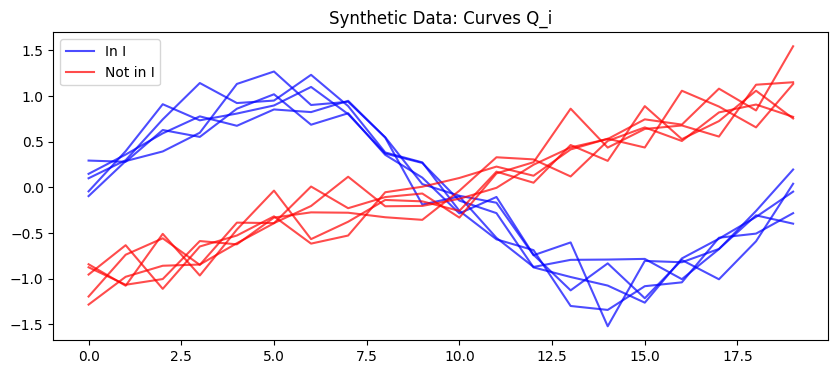

Optimizing for P (len=20) and Delta...
In-set (I): [0, 1, 2, 3, 4]
Out-set (not I): [5, 6, 7, 8, 9]
Epoch 0: Loss = 75.1244, Delta = 1.1000, Avg dist (In) = 15.9249, Avg dist (Out) = 27.3311


/var/folders/qc/gl6rlk253fs0zbvjtf9kjsmw0000gn/T/ipykernel_24191/2756431438.py:72: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  avg_in = torch.tensor(dist_in).mean().item() if dist_in else 0


Epoch 50: Loss = 0.0000, Delta = 3.1298, Avg dist (In) = 1.9576, Avg dist (Out) = 15.0664
Epoch 100: Loss = 0.0000, Delta = 3.1575, Avg dist (In) = 1.9362, Avg dist (Out) = 14.9787
Epoch 150: Loss = 0.0000, Delta = 3.1577, Avg dist (In) = 1.9361, Avg dist (Out) = 14.9781
Epoch 200: Loss = 0.0000, Delta = 3.1577, Avg dist (In) = 1.9361, Avg dist (Out) = 14.9781
Epoch 250: Loss = 0.0000, Delta = 3.1577, Avg dist (In) = 1.9361, Avg dist (Out) = 14.9781


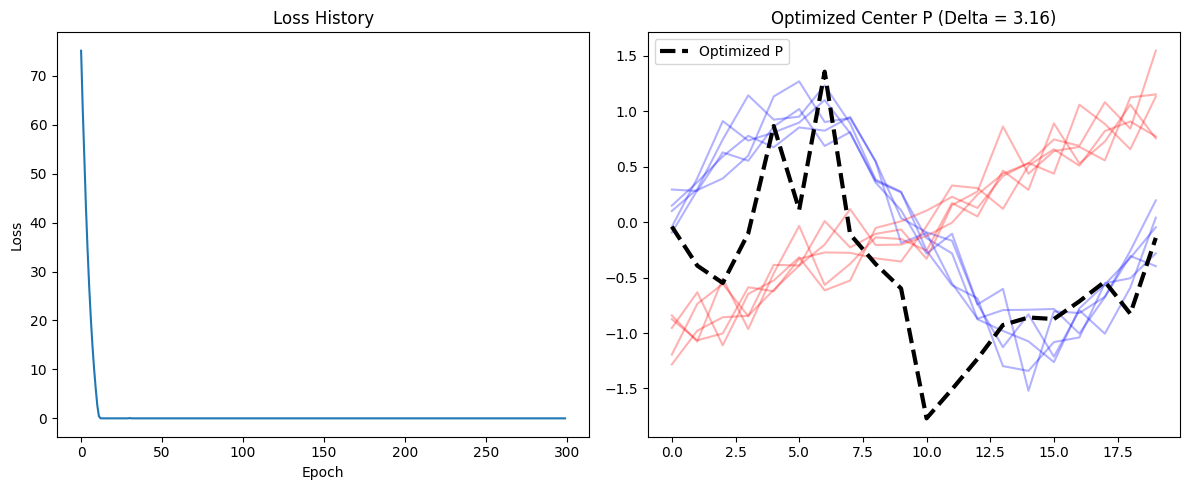

Final Delta: 3.1577
Final Distances:
  Q_0 (In I): Dist = 1.6225 -> INSIDE [OK]
  Q_1 (In I): Dist = 2.3981 -> INSIDE [OK]
  Q_2 (In I): Dist = 2.5603 -> INSIDE [OK]
  Q_3 (In I): Dist = 1.2339 -> INSIDE [OK]
  Q_4 (In I): Dist = 1.8658 -> INSIDE [OK]
  Q_5 (Not I): Dist = 16.5691 -> OUTSIDE [OK]
  Q_6 (Not I): Dist = 12.0991 -> OUTSIDE [OK]
  Q_7 (Not I): Dist = 14.1661 -> OUTSIDE [OK]
  Q_8 (Not I): Dist = 17.0511 -> OUTSIDE [OK]
  Q_9 (Not I): Dist = 15.0051 -> OUTSIDE [OK]


In [3]:
# Define the optimization function
def optimize_ball(Qs, I, k, gamma=1.0, lr=0.1, epochs=500):
    """
    Find P and Delta using gradient descent.
    Qs: List of time series (tensors).
    I: List of indices that should be INSIDE the ball.
    k: Length of the center P.
    """
    # Convert Qs to tensors if not already
    Qs = [q.clone().detach().float() if isinstance(q, torch.Tensor) else torch.tensor(q, dtype=torch.float32) for q in Qs]
    
    # Initialize P (the center of the ball)
    # A good initialization is the mean of the sequences in I, interpolated to length k.
    # For now, let's just use random initialization
    P = torch.nn.Parameter(torch.randn(k, requires_grad=True))

    # Initialize Delta (radius)
    # Start with a reasonable guess, e.g., 1.0 or mean pairwise distance
    Delta = torch.nn.Parameter(torch.tensor(1.0, requires_grad=True))

    optimizer = optim.Adam([P, Delta], lr=lr)
    
    # SoftDTW module
    sdtw = SoftDTW(gamma=gamma)

    losses = []
    
    # Determine indices NOT in I
    all_indices = set(range(len(Qs)))
    I_set = set(I)
    not_I = list(all_indices - I_set)
    I_list = list(I_set)
    
    print(f"Optimizing for P (len={k}) and Delta...")
    print(f"In-set (I): {I_list}")
    print(f"Out-set (not I): {not_I}")

    for epoch in range(epochs):
        optimizer.zero_grad()
        
        loss = 0
        current_distances = []
        
        # Calculate distances to P for all Qs
        # Note: This loop can be slow for many Qs. Vectorization would be better but requires batched SoftDTW.
        # Given potential constraints, we do loop for clarity.
        
        # Determine violation for Q_i (i in I): d(Q_i, P) < Delta
        # We want d(Q_i, P) - Delta < 0
        # Penalize if d(Q_i, P) - Delta > 0 -> ReLU(d - Delta)
        dist_in = []
        for i in I_list:
            d = sdtw(Qs[i], P)
            loss += torch.relu(d - Delta + 0.1) # Add margin
            dist_in.append(d)
            
        # Determine violation for Q_j (j not in I): d(Q_j, P) > Delta
        # We want Delta - d(Q_j, P) < 0
        # Penalize if Delta - d(Q_j, P) > 0 -> ReLU(Delta - d)
        dist_out = []
        for j in not_I:
            d = sdtw(Qs[j], P)
            loss += torch.relu(Delta - d + 0.1) # Add margin
            dist_out.append(d)

        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())

        if epoch % 50 == 0:
            avg_in = torch.tensor(dist_in).mean().item() if dist_in else 0
            avg_out = torch.tensor(dist_out).mean().item() if dist_out else 0
            print(f"Epoch {epoch}: Loss = {loss.item():.4f}, Delta = {Delta.item():.4f}, "
                  f"Avg dist (In) = {avg_in:.4f}, Avg dist (Out) = {avg_out:.4f}")

    return P.detach(), Delta.detach(), losses

# ---------------------------------------------------------
# Synthetic Data Generation
# ---------------------------------------------------------
def generate_data():
    # Generate two clusters of time series
    # Cluster 1: Sine waves
    # Cluster 2: Lines with noise
    
    t = np.linspace(0, 2*np.pi, 20)
    
    Qs = []
    labels = []
    
    # Cluster 1 (Sine-like) -> Target set I
    for _ in range(5):
        noise = np.random.normal(0, 0.2, len(t))
        q = np.sin(t) + noise
        Qs.append(q)
        labels.append(1) # In set I
        
    # Cluster 2 (Line-like) -> Not in I
    for _ in range(5):
        noise = np.random.normal(0, 0.2, len(t))
        q = np.linspace(-1, 1, 20) + noise
        Qs.append(q)
        labels.append(0) # Not in I
        
    I = [i for i, label in enumerate(labels) if label == 1]
    
    return Qs, I

# ---------------------------------------------------------
# Run Optimization
# ---------------------------------------------------------
Qs, I = generate_data()

# Plot the generated data
plt.figure(figsize=(10, 4))
for i, q in enumerate(Qs):
    color = 'blue' if i in I else 'red'
    label = 'In I' if i in I else 'Not in I'
    if i == I[0] or i == [x for x in range(len(Qs)) if x not in I][0]: # Label only once
        plt.plot(q, color=color, alpha=0.7, label=label)
    else:
        plt.plot(q, color=color, alpha=0.7)
plt.title("Synthetic Data: Curves Q_i")
plt.legend()
plt.show()

# Run optimization
# P length k=20 (same as original, but can be anything)
P_opt, Delta_opt, history = optimize_ball(Qs, I, k=20, gamma=0.1, lr=0.1, epochs=300)

# ---------------------------------------------------------
# Visualization of Results
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Plot Learning Curve
plt.subplot(1, 2, 1)
plt.plot(history)
plt.title("Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Plot Resulting P and separation
plt.subplot(1, 2, 2)
# Plot Qs again
for i, q in enumerate(Qs):
    color = 'blue' if i in I else 'red'
    plt.plot(q, color=color, alpha=0.3)
    
# Plot optimized P
plt.plot(P_opt, color='black', linewidth=3, linestyle='--', label='Optimized P')
plt.title(f"Optimized Center P (Delta = {Delta_opt.item():.2f})")
plt.legend()

plt.tight_layout()
plt.show()

# Print final verification
sdtw_final = SoftDTW(gamma=0.1)
print(f"Final Delta: {Delta_opt.item():.4f}")
print("Final Distances:")
for i, q in enumerate(Qs):
    d = sdtw_final(torch.tensor(q, dtype=torch.float32), P_opt).item()
    status = "INSIDE" if d < Delta_opt.item() else "OUTSIDE"
    correct = (i in I and status == "INSIDE") or (i not in I and status == "OUTSIDE")
    mark = "OK" if correct else "FAIL"
    print(f"  Q_{i} ({'In I' if i in I else 'Not I'}): Dist = {d:.4f} -> {status} [{mark}]")


In [5]:
import itertools
import csv
import os
import math
import io
import contextlib


def to_1d_numpy(curve):
    """Convert tensor/array-like curve to a 1D numpy array."""
    if isinstance(curve, torch.Tensor):
        arr = curve.detach().cpu().numpy()
    else:
        arr = np.asarray(curve)
    return arr.reshape(-1)


def hard_dtw_distance(x, y):
    """
    Classic (hard) DTW distance with squared Euclidean local cost.
    """
    x = to_1d_numpy(x)
    y = to_1d_numpy(y)

    n, m = len(x), len(y)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = (x[i - 1] - y[j - 1]) ** 2
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])

    return float(D[n, m])


def validate_witness_hard_dtw(P, Qs, I):
    """
    Validate witness using hard DTW:
    max_{i in I} DTW(P,Q_i) < min_{j not in I} DTW(P,Q_j)

    Returns:
        (is_valid, max_in, min_out, all_distances)
    """
    n = len(Qs)
    I_set = set(I)
    not_I = [j for j in range(n) if j not in I_set]

    distances = [hard_dtw_distance(P, Qs[t]) for t in range(n)]

    # Empty/full subsets are vacuous for this strict split metric
    if len(I_set) == 0 or len(not_I) == 0:
        return True, math.nan, math.nan, distances

    max_in = max(distances[i] for i in I_set)
    min_out = min(distances[j] for j in not_I)
    is_valid = max_in < min_out
    return is_valid, float(max_in), float(min_out), distances


# Robust wrapper around optimize_ball
def optimize_ball_robust(
    Qs,
    I,
    k,
    gamma=1.0,
    lr=0.1,
    epochs=500,
    loss_threshold=1e-4,
    retries=3,
    require_hard_dtw_validation=True,
    verbose=False,
):
    """
    Tries to find a solution. Returns:
      (success, P, Delta, max_in_dtw, min_out_dtw, hard_valid)

    If require_hard_dtw_validation=True, a candidate is accepted only if
    hard DTW strict separation holds.
    """
    for attempt in range(retries):
        # Suppress noisy optimization output unless explicitly requested
        if verbose:
            P_opt, Delta_opt, losses = optimize_ball(Qs, I, k, gamma, lr, epochs)
        else:
            with contextlib.redirect_stdout(io.StringIO()):
                P_opt, Delta_opt, losses = optimize_ball(Qs, I, k, gamma, lr, epochs)

        final_loss = losses[-1]

        if final_loss < loss_threshold:
            if require_hard_dtw_validation:
                hard_valid, max_in, min_out, _ = validate_witness_hard_dtw(P_opt, Qs, I)
                if hard_valid:
                    return True, P_opt, Delta_opt, max_in, min_out, True
            else:
                return True, P_opt, Delta_opt, math.nan, math.nan, True

    return False, None, None, math.nan, math.nan, False


def check_shattering(Qs, k, gamma=1.0, verbose=False, validation = True):
    """
    Checks if the set Qs is shattered.

    Returns:
      is_shattered (bool)
      witnesses (dict):
          key   = tuple subset I
          value = {
              'P': numpy array,
              'Delta': float,
              'max_in_dtw': float,
              'min_out_dtw': float,
              'hard_dtw_valid': bool
          }
    """
    d = len(Qs)
    indices = list(range(d))
    witnesses = {}

    # Iterate all subsets
    for r in range(d + 1):
        for subset_I in itertools.combinations(indices, r):
            I_list = list(subset_I)

            success, P_opt, Delta_opt, max_in_dtw, min_out_dtw, hard_valid = optimize_ball_robust(
                Qs,
                I_list,
                k,
                gamma=gamma,
                epochs=300,
                retries=2,
                require_hard_dtw_validation=validation,
                verbose=verbose,
            )

            if not success:
                if verbose:
                    print(f"  Failed subset (Soft-DTW optimization and/or hard-DTW validation): {I_list}")
                return False, witnesses

            witnesses[tuple(I_list)] = {
                "P": to_1d_numpy(P_opt),
                "Delta": float(Delta_opt.item() if isinstance(Delta_opt, torch.Tensor) else Delta_opt),
                "max_in_dtw": max_in_dtw,
                "min_out_dtw": min_out_dtw,
                "hard_dtw_valid": bool(hard_valid),
            }

    return True, witnesses


def save_witnesses_csv(shattered_set, witnesses, out_csv_path, verbose=False):
    """
    Save CSV in requested format:
      1) First: the shattered set points
      2) Then: one row per tested subset I with witness P and Delta

    CSV columns:
      row_type, point_index, subset_I, Q_values, P_values, Delta,
      hard_dtw_max_in, hard_dtw_min_out, hard_dtw_valid
    """
    os.makedirs(os.path.dirname(out_csv_path) or ".", exist_ok=True)

    with open(out_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "row_type",
            "point_index",
            "subset_I",
            "Q_values",
            "P_values",
            "Delta",
            "hard_dtw_max_in",
            "hard_dtw_min_out",
            "hard_dtw_valid",
        ])

        # Section 1: shattered points
        writer.writerow(["SHATTERED_SET", "", "", "", "", "", "", "", ""])
        for idx, q in enumerate(shattered_set):
            q_vals = ";".join([f"{v:.10g}" for v in to_1d_numpy(q)])
            writer.writerow(["POINT", idx, "", q_vals, "", "", "", "", ""])

        # Section separator
        writer.writerow(["WITNESSES", "", "", "", "", "", "", "", ""])

        # Section 2: witnesses per tested subset
        for subset_key in sorted(witnesses.keys(), key=lambda t: (len(t), t)):
            w = witnesses[subset_key]
            subset_str = "{" + ",".join(map(str, subset_key)) + "}"
            p_vals = ";".join([f"{v:.10g}" for v in w["P"]])
            writer.writerow([
                "SUBSET_WITNESS",
                "",
                subset_str,
                "",
                p_vals,
                f"{w['Delta']:.10g}",
                "" if math.isnan(w["max_in_dtw"]) else f"{w['max_in_dtw']:.10g}",
                "" if math.isnan(w["min_out_dtw"]) else f"{w['min_out_dtw']:.10g}",
                int(bool(w["hard_dtw_valid"])),
            ])

    if verbose:
        print(f"Witness CSV saved to: {out_csv_path}")


def _with_run_suffix(path, run_idx_1based, num_runs):
    """Create per-run CSV path when num_runs > 1."""
    if num_runs <= 1:
        return path
    root, ext = os.path.splitext(path)
    if ext == "":
        ext = ".csv"
    return f"{root}_run{run_idx_1based}{ext}"


def _single_sequential_run(
    m,
    k,
    gamma,
    max_retries_step4,
    max_d,
    witness_csv_path,
    run_idx,
    num_runs,
    verbose,
    validation = True,
):
    """Run one sequential estimation attempt."""
    d = 0
    X = []
    witnesses_final = {}

    while d < max_d:
        # Only concise progress output
        print(f"Run {run_idx}/{num_runs} | current d={d}")
        success_step3 = False

        for _retry in range(max_retries_step4 + 1):
            new_Q = torch.randn(m, 1)
            current_X = X + [new_Q]
            is_shattered, current_witnesses = check_shattering(current_X, k, gamma, verbose=verbose, validation=validation)

            if is_shattered:
                X = current_X
                witnesses_final = current_witnesses
                d += 1
                success_step3 = True
                break

        if not success_step3:
            out_path = _with_run_suffix(witness_csv_path, run_idx, num_runs)
            save_witnesses_csv(X, witnesses_final, out_path, verbose=verbose)
            return d, X, witnesses_final

    out_path = _with_run_suffix(witness_csv_path, run_idx, num_runs)
    save_witnesses_csv(X, witnesses_final, out_path, verbose=verbose)
    return d, X, witnesses_final


def sequential_capacity_estimation(
    m,
    k,
    gamma=1.0,
    max_retries_step4=5,
    max_d=15,
    witness_csv_path="witnesses_sequential_capacity.csv",
    num_runs=1,
    verbose=False,
    validation = True,
):
    """
    Estimates shattering capacity for Q in R^m and P in R^k.

    Parameters
    ----------
    num_runs : int
        Number of independent sequential runs.
    verbose : bool
        If False (default), suppress detailed logs and print only current d.

    Returns
    -------
    If num_runs == 1:
        (d_max, X_final, witnesses_final)
    If num_runs > 1:
        (best_d, best_X, best_witnesses, all_d_values)
    """
    if num_runs < 1:
        raise ValueError("num_runs must be >= 1")

    all_results = []
    all_d_values = []

    for run_idx in range(1, num_runs + 1):
        d, X, witnesses = _single_sequential_run(
            m=m,
            k=k,
            gamma=gamma,
            max_retries_step4=max_retries_step4,
            max_d=max_d,
            witness_csv_path=witness_csv_path,
            run_idx=run_idx,
            num_runs=num_runs,
            verbose=verbose,
            validation=validation,
        )
        all_results.append((d, X, witnesses))
        all_d_values.append(d)
        print(f"Run {run_idx}/{num_runs} finished with d_max={d}")

    if num_runs == 1:
        return all_results[0]

    best_idx = int(np.argmax(all_d_values))
    best_d, best_X, best_witnesses = all_results[best_idx]
    print(f"Best over {num_runs} runs: d_max={best_d}")
    return best_d, best_X, best_witnesses, all_d_values


# Example run
# - minimal console output
# - multiple independent runs
result = sequential_capacity_estimation(
    m=2,
    k=2,
    gamma=0.1,
    max_retries_step4=3,
    witness_csv_path="witnesses_m100_k100.csv",
    num_runs=3,
    validation= False,
    verbose=False,
)

if len(result) == 3:
    est_d, est_X, est_witnesses = result
    print(f"Estimated Capacity: {est_d}")
    print(f"Number of saved witnesses: {len(est_witnesses)}")
else:
    est_d, est_X, est_witnesses, all_ds = result
    print(f"Run d_max values: {all_ds}")
    print(f"Best Estimated Capacity: {est_d}")
    print(f"Number of saved witnesses (best run): {len(est_witnesses)}")

Run 1/3 | current d=0
Run 1/3 | current d=1
Run 1/3 | current d=2
Run 1/3 | current d=3
Run 1/3 finished with d_max=3
Run 2/3 | current d=0
Run 2/3 | current d=1
Run 2/3 | current d=2
Run 2/3 | current d=3
Run 2/3 finished with d_max=3
Run 3/3 | current d=0
Run 3/3 | current d=1
Run 3/3 | current d=2
Run 3/3 finished with d_max=2
Best over 3 runs: d_max=3
Run d_max values: [3, 3, 2]
Best Estimated Capacity: 3
Number of saved witnesses (best run): 8


Running sequential capacity estimation on grid...
  (m=1, k=1) ... Run 1/1 | current d=0
Run 1/1 | current d=1
Run 1/1 | current d=2
Run 1/1 finished with d_max=2
d_max=2


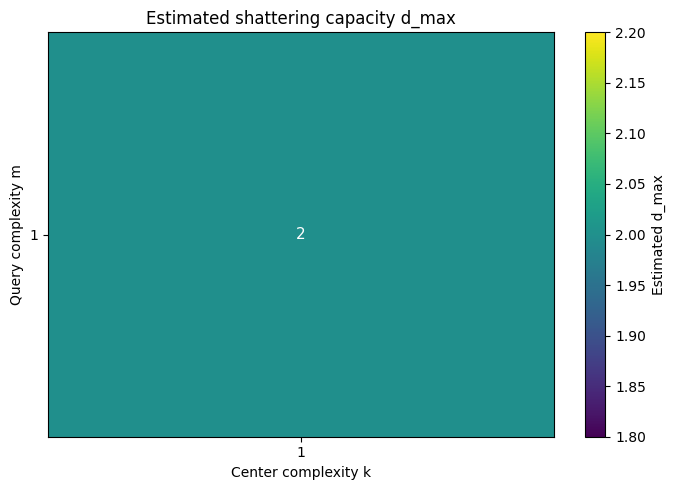


Capacity grid (rows=m, cols=k):
[[2.]]


In [7]:
# Heatmap of estimated shattering capacity over a grid of (k, m)
import numpy as np
import matplotlib.pyplot as plt

# Small grid to keep runtime reasonable (you can expand this)
k_values = [1]
m_values = [1]

# Runtime controls
max_d_for_grid = 4
max_retries_for_grid = 1
gamma_for_grid = 0.1

capacity_grid = np.zeros((len(m_values), len(k_values)), dtype=float)


def _extract_dmax(result):
    """Compatibility helper for different return signatures."""
    if isinstance(result, tuple):
        return int(result[0])
    return int(result)


print("Running sequential capacity estimation on grid...")
for mi, m in enumerate(m_values):
    for ki, k in enumerate(k_values):
        print(f"  (m={m}, k={k}) ...", end=" ")
        result = sequential_capacity_estimation(
            m=m,
            k=k,
            gamma=gamma_for_grid,
            max_retries_step4=max_retries_for_grid,
            max_d=max_d_for_grid,
        )
        dmax = _extract_dmax(result)
        capacity_grid[mi, ki] = dmax
        print(f"d_max={dmax}")


# Plot heatmap
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(capacity_grid, cmap="viridis", aspect="auto", origin="upper")

ax.set_xticks(np.arange(len(k_values)))
ax.set_xticklabels(k_values)
ax.set_yticks(np.arange(len(m_values)))
ax.set_yticklabels(m_values)
ax.set_xlabel("Center complexity k")
ax.set_ylabel("Query complexity m")
ax.set_title("Estimated shattering capacity d_max")

# Annotate cells
for i in range(len(m_values)):
    for j in range(len(k_values)):
        ax.text(j, i, int(capacity_grid[i, j]), ha="center", va="center", color="white", fontsize=11)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Estimated d_max")

plt.tight_layout()
plt.show()

print("\nCapacity grid (rows=m, cols=k):")
print(capacity_grid)


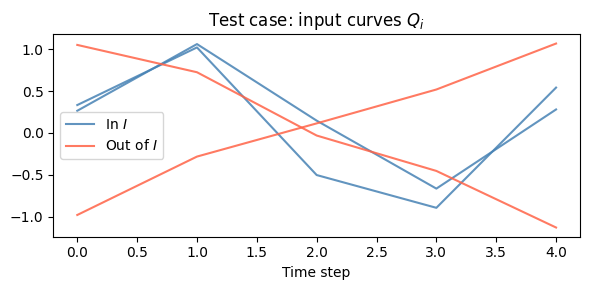

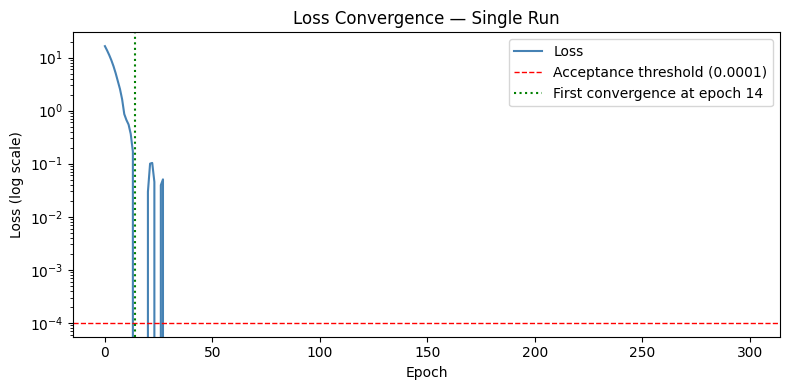

Final loss : 0.00e+00
Converged  : Yes, epoch 14


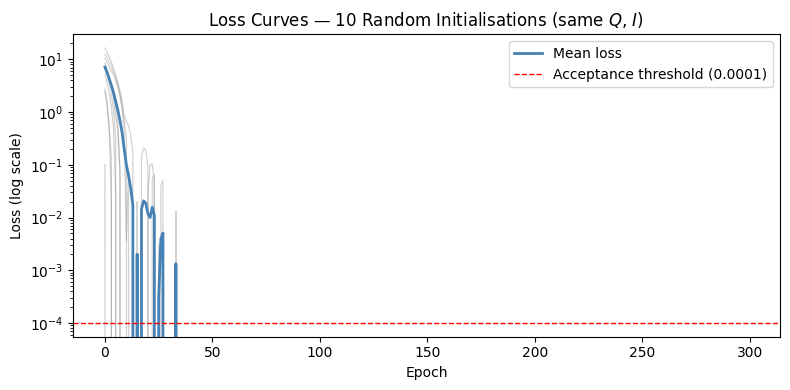

Converged : 10/10 runs
Epochs to convergence per run : [14, 1, 4, 8, 11, 8, 12, 6, 6, 4]


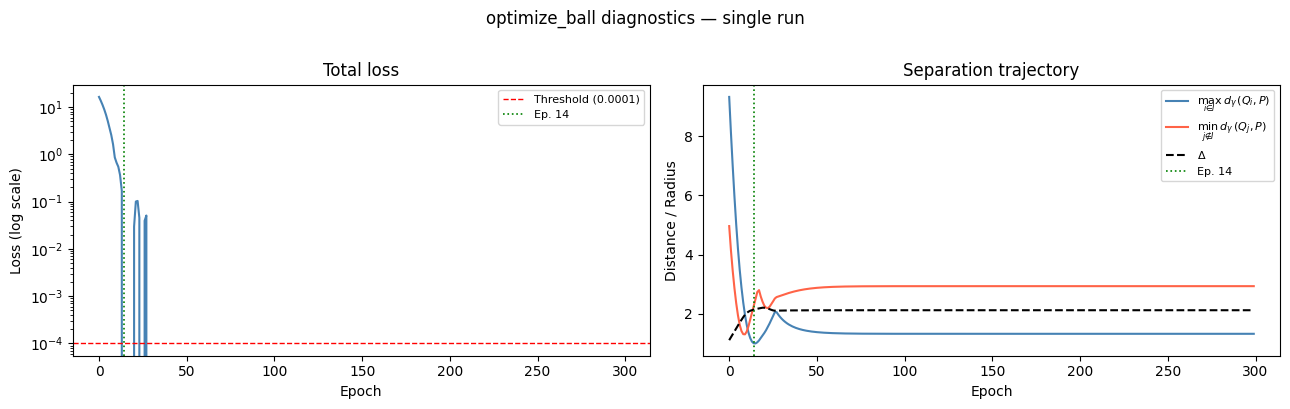

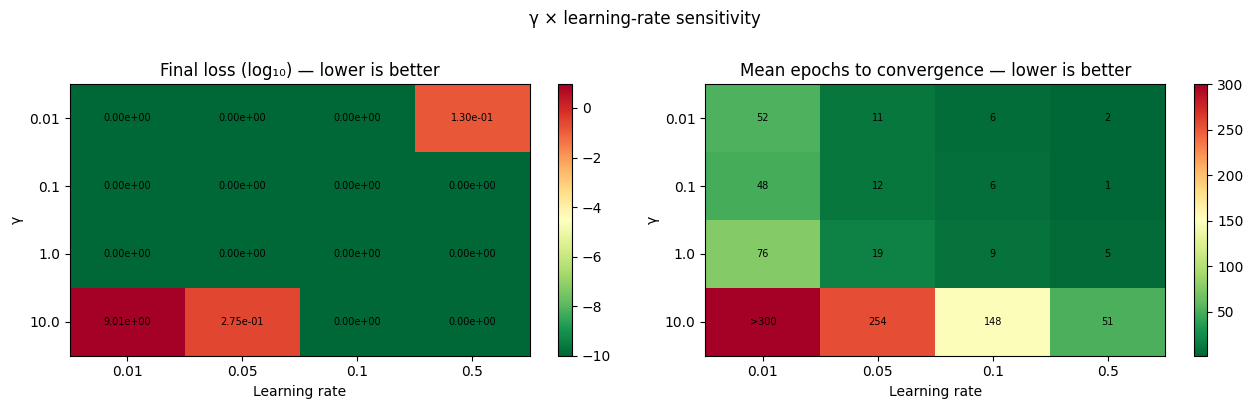

In [8]:

# ─────────────────────────────────────────────────────────────────────────────
# OPTIMIZE_BALL DIAGNOSTICS
# Plots: test-case overview · single-run convergence · multi-init variance ·
#        separation trajectory · γ × lr sensitivity heatmap
# ─────────────────────────────────────────────────────────────────────────────

SEED       = 0
M_TEST     = 5      # series length (short → fast)
K_TEST     = 6      # center length
GAMMA_D    = 0.1
LR_D       = 0.1
EPOCHS_D   = 300
MARGIN_D   = 0.1    # must match the hard-coded margin in optimize_ball
THRESHOLD  = 1e-4
N_INITS    = 10     # number of random initialisations for Plot 2


# ── Fixed reproducible test case ─────────────────────────────────────────────
def make_test_case(seed=SEED, m=M_TEST):
    """Return (Qs, I): 2 sine-like 'in' series and 2 linear 'out' series."""
    rng = np.random.RandomState(seed)
    t   = np.linspace(0, 2 * np.pi, m)
    Qs  = [
        torch.tensor(np.sin(t)            + rng.randn(m) * 0.15, dtype=torch.float32),
        torch.tensor(np.sin(t + 0.5)      + rng.randn(m) * 0.15, dtype=torch.float32),
        torch.tensor(np.linspace(-1,  1, m) + rng.randn(m) * 0.15, dtype=torch.float32),
        torch.tensor(np.linspace( 1, -1, m) + rng.randn(m) * 0.15, dtype=torch.float32),
    ]
    return Qs, [0, 1]


# ── Extended optimize_ball with per-epoch tracing ────────────────────────────
def optimize_ball_traced(Qs, I, k, gamma=GAMMA_D, lr=LR_D,
                         epochs=EPOCHS_D, margin=MARGIN_D, seed=None):
    """
    Identical logic to optimize_ball but also returns:
      max_in_hist  – max sdtw(Q_i, P) for i in I, per epoch
      min_out_hist – min sdtw(Q_j, P) for j not in I, per epoch
      delta_hist   – Delta value per epoch
    """
    if seed is not None:
        torch.manual_seed(seed)
    Qs = [q.clone().detach().float() if isinstance(q, torch.Tensor)
          else torch.tensor(q, dtype=torch.float32) for q in Qs]

    P     = nn.Parameter(torch.randn(k))
    Delta = nn.Parameter(torch.tensor(1.0))
    optimizer = optim.Adam([P, Delta], lr=lr)
    sdtw = SoftDTW(gamma=gamma)

    I_list = list(set(I))
    not_I  = list(set(range(len(Qs))) - set(I))

    losses, max_in_hist, min_out_hist, delta_hist = [], [], [], []

    for _ in range(epochs):
        optimizer.zero_grad()
        dist_in  = [sdtw(Qs[i], P) for i in I_list]
        dist_out = [sdtw(Qs[j], P) for j in not_I]

        loss = (sum(torch.relu(d - Delta + margin) for d in dist_in) +
                sum(torch.relu(Delta - d + margin) for d in dist_out))

        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        max_in_hist.append(max(d.item() for d in dist_in)  if dist_in  else float('nan'))
        min_out_hist.append(min(d.item() for d in dist_out) if dist_out else float('nan'))
        delta_hist.append(Delta.item())

    return P.detach(), Delta.detach(), losses, max_in_hist, min_out_hist, delta_hist


Qs, I = make_test_case()


# ════════════════════════════════════════════════════════════════════════════
# PLOT 0 — Test-case overview
# ════════════════════════════════════════════════════════════════════════════
out_idx = [j for j in range(len(Qs)) if j not in I]

fig, ax = plt.subplots(figsize=(6, 3))
for idx, q in enumerate(Qs):
    c   = 'steelblue' if idx in I else 'tomato'
    lbl = ('In $I$' if idx == I[0] else ('Out of $I$' if idx == out_idx[0] else None))
    ax.plot(q.numpy(), color=c, alpha=0.85, label=lbl)
ax.set_title('Test case: input curves $Q_i$')
ax.set_xlabel('Time step')
ax.legend()
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Single-run convergence curve
# ════════════════════════════════════════════════════════════════════════════
_, _, losses1, max_in1, min_out1, delta1 = optimize_ball_traced(Qs, I, K_TEST, seed=SEED)

conv_epoch = next((e for e, l in enumerate(losses1) if l < THRESHOLD), None)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses1, color='steelblue', label='Loss')
ax.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1,
           label=f'Acceptance threshold ({THRESHOLD})')
if conv_epoch is not None:
    ax.axvline(conv_epoch, color='green', linestyle=':', linewidth=1.5,
               label=f'First convergence at epoch {conv_epoch}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log scale)')
ax.set_yscale('log')
ax.set_title('Loss Convergence — Single Run')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final loss : {losses1[-1]:.2e}")
print(f"Converged  : {'Yes, epoch ' + str(conv_epoch) if conv_epoch is not None else 'No'}")


# ════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Multiple random initialisations (same Q, I)
# ════════════════════════════════════════════════════════════════════════════
all_losses  = []
conv_epochs = []

for s in range(N_INITS):
    _, _, lh, _, _, _ = optimize_ball_traced(Qs, I, K_TEST, seed=s)
    all_losses.append(lh)
    ce = next((e for e, l in enumerate(lh) if l < THRESHOLD), None)
    conv_epochs.append(ce if ce is not None else EPOCHS_D)

fig, ax = plt.subplots(figsize=(8, 4))
for lh in all_losses:
    ax.plot(lh, color='grey', alpha=0.35, linewidth=0.9)
ax.plot(np.mean(all_losses, axis=0), color='steelblue', linewidth=2, label='Mean loss')
ax.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1,
           label=f'Acceptance threshold ({THRESHOLD})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log scale)')
ax.set_yscale('log')
ax.set_title(f'Loss Curves — {N_INITS} Random Initialisations (same $Q$, $I$)')
ax.legend()
plt.tight_layout()
plt.show()

n_conv = sum(e < EPOCHS_D for e in conv_epochs)
print(f"Converged : {n_conv}/{N_INITS} runs")
print(f"Epochs to convergence per run : {conv_epochs}")


# ════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Separation trajectory (max_in, min_out, Δ over epochs)
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(losses1, color='steelblue')
ax.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1,
           label=f'Threshold ({THRESHOLD})')
if conv_epoch is not None:
    ax.axvline(conv_epoch, color='green', linestyle=':', linewidth=1.2,
               label=f'Ep. {conv_epoch}')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Total loss')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(max_in1,  color='steelblue', label=r'$\max_{i \in I}\,d_\gamma(Q_i, P)$')
ax.plot(min_out1, color='tomato',    label=r'$\min_{j \notin I}\,d_\gamma(Q_j, P)$')
ax.plot(delta1,   color='black', linestyle='--', label=r'$\Delta$')
if conv_epoch is not None:
    ax.axvline(conv_epoch, color='green', linestyle=':', linewidth=1.2,
               label=f'Ep. {conv_epoch}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Distance / Radius')
ax.set_title('Separation trajectory')
ax.legend(fontsize=8)

plt.suptitle('optimize_ball diagnostics — single run', y=1.01)
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# PLOT 4 — γ × lr sensitivity heatmap
# ════════════════════════════════════════════════════════════════════════════
gammas_grid   = [0.01, 0.1, 1.0, 10.0]
lrs_grid      = [0.01, 0.05, 0.1, 0.5]
N_SEEDS_HEAT  = 3   # average over a few seeds for stability

final_loss_grid = np.zeros((len(gammas_grid), len(lrs_grid)))
conv_epoch_grid = np.zeros((len(gammas_grid), len(lrs_grid)))

for gi, g in enumerate(gammas_grid):
    for li, lr in enumerate(lrs_grid):
        fl_list, ce_list = [], []
        for s in range(N_SEEDS_HEAT):
            _, _, lh, _, _, _ = optimize_ball_traced(Qs, I, K_TEST,
                                                     gamma=g, lr=lr, seed=s)
            fl_list.append(lh[-1])
            ce_list.append(next((e for e, l in enumerate(lh) if l < THRESHOLD), EPOCHS_D))
        final_loss_grid[gi, li] = np.mean(fl_list)
        conv_epoch_grid[gi, li] = np.mean(ce_list)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im0 = axes[0].imshow(np.log10(final_loss_grid + 1e-10), aspect='auto', cmap='RdYlGn_r')
axes[0].set_xticks(range(len(lrs_grid)));    axes[0].set_xticklabels(lrs_grid)
axes[0].set_yticks(range(len(gammas_grid))); axes[0].set_yticklabels(gammas_grid)
axes[0].set_xlabel('Learning rate')
axes[0].set_ylabel('γ')
axes[0].set_title('Final loss (log₁₀) — lower is better')
for gi in range(len(gammas_grid)):
    for li in range(len(lrs_grid)):
        axes[0].text(li, gi, f"{final_loss_grid[gi, li]:.2e}",
                     ha='center', va='center', fontsize=7)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(conv_epoch_grid, aspect='auto', cmap='RdYlGn_r')
axes[1].set_xticks(range(len(lrs_grid)));    axes[1].set_xticklabels(lrs_grid)
axes[1].set_yticks(range(len(gammas_grid))); axes[1].set_yticklabels(gammas_grid)
axes[1].set_xlabel('Learning rate')
axes[1].set_ylabel('γ')
axes[1].set_title(f'Mean epochs to convergence — lower is better')
for gi in range(len(gammas_grid)):
    for li in range(len(lrs_grid)):
        val = conv_epoch_grid[gi, li]
        axes[1].text(li, gi,
                     f'{int(val)}' if val < EPOCHS_D else f'>{EPOCHS_D}',
                     ha='center', va='center', fontsize=7)
plt.colorbar(im1, ax=axes[1])

plt.suptitle('γ × learning-rate sensitivity', y=1.01)
plt.tight_layout()
plt.show()


In [12]:

# ─────────────────────────────────────────────────────────────────────────────
# SHATTERING TEST: fixed point set
#   Q0 = [1,  -1]
#   Q1 = [0.5,-1.5]
#   Q2 = [0,  -2]
#   Q3 = [-1, -3]
# Each point is a length-2 time series (m=2).
# We test shattering for several center complexities k.
# ─────────────────────────────────────────────────────────────────────────────

FIXED_Qs = [
    torch.tensor([1.0,  -1.0]),
    torch.tensor([0.5,  -1.5]),
    torch.tensor([0.0,  -2.0]),
    torch.tensor([-0.5, -2.5]),
    torch.tensor([-1.0, -3.0]),
]

GAMMA_TEST  = 0.1
K_VALUES    = [10,15,20]

print("Fixed point set:")
for i, q in enumerate(FIXED_Qs):
    print(f"  Q{i} = {q.tolist()}")
print()

results_table = []

for k in K_VALUES:
    print(f"── k = {k} ─────────────────────────────────────")
    is_shattered, witnesses = check_shattering(
        FIXED_Qs, k=k, gamma=GAMMA_TEST, verbose=False, validation=False
    )
    n_found = len(witnesses)
    n_total = 2 ** len(FIXED_Qs)
    print(f"   Shattered : {is_shattered}  ({n_found}/{n_total} subsets solved)")
    results_table.append((k, is_shattered, n_found, n_total))
    print()

# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 50)
print(f"{'k':>4}  {'Shattered':>10}  {'Subsets solved':>15}")
print("-" * 50)
for k, shattered, found, total in results_table:
    print(f"{k:>4}  {str(shattered):>10}  {found:>6} / {total:<6}")
print("=" * 50)


Fixed point set:
  Q0 = [1.0, -1.0]
  Q1 = [0.5, -1.5]
  Q2 = [0.0, -2.0]
  Q3 = [-0.5, -2.5]
  Q4 = [-1.0, -3.0]

── k = 10 ─────────────────────────────────────
   Shattered : False  (11/32 subsets solved)

── k = 15 ─────────────────────────────────────
   Shattered : False  (8/32 subsets solved)

── k = 20 ─────────────────────────────────────
   Shattered : False  (11/32 subsets solved)

   k   Shattered   Subsets solved
--------------------------------------------------
  10       False      11 / 32    
  15       False       8 / 32    
  20       False      11 / 32    
